# 19 - Ensemble Extensions

This notebook extends EnergyTypeNet beyond the existing soft-voting and stacking
workflow. It adds custom Bagging and AdaBoost models that reuse
`DecisionTreeClassifierCustom`, then compares them with sklearn ensemble
baselines, XGBoost, and regression ensembles.

EnergyTypeNet remains the primary dataset. Synthetic data is used only for
controlled ensemble theory demonstrations, and California Housing is used only
for a larger regression ensemble benchmark when available.


In [12]:
import sys
import os
import time
import warnings

sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification, fetch_california_housing
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    BaggingRegressor,
    ExtraTreesClassifier,
    ExtraTreesRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, r2_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from xgboost import XGBClassifier, XGBRegressor

from src.data import CLASSES, FEATURE_COLS, load_features, load_raw
from src.models import (
    AdaBoostClassifierCustom,
    AttentionClassifier,
    BaggingClassifierCustom,
    BaggingRegressorCustom,
    DecisionTreeClassifierCustom,
    DecisionTreeRegressorCustom,
    LogisticRegressionOvR,
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
RANDOM_STATE = 42


## 1. Ensemble Theory - Why Combining Models Works

For an average of `M` predictors, the variance term can shrink roughly like
`variance / M` when model errors are independent. In practice, covariance
between model errors sets the floor:

`E[ensemble error] = bias^2 + variance / M + (1 - 1 / M) * covariance`

Ensembles help when the individual models are better than random and make
different mistakes.


**Runtime note.** The bootstrap study uses bounded custom trees and a moderate number of repetitions because these trees are implemented from scratch in NumPy. This keeps the notebook runnable while preserving the variance-reduction demonstration.


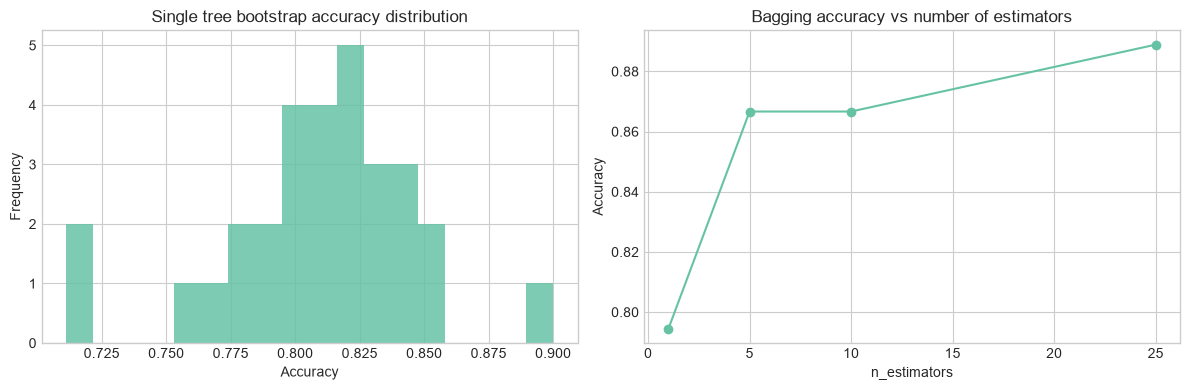

,n_estimators,test_accuracy
0,1,0.794444
1,5,0.866667
2,10,0.866667
3,25,0.888889


In [13]:
X_syn, y_syn = make_classification(
    n_samples=600,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    random_state=RANDOM_STATE,
)
X_train_syn, X_test_syn, y_train_syn, y_test_syn = train_test_split(
    X_syn, y_syn, test_size=0.3, stratify=y_syn, random_state=RANDOM_STATE
)

rng = np.random.RandomState(RANDOM_STATE)
single_tree_scores = []
for _ in range(30):
    idx = rng.choice(len(X_train_syn), len(X_train_syn), replace=True)
    tree = DecisionTreeClassifierCustom(max_depth=6).fit(X_train_syn[idx], y_train_syn[idx])
    single_tree_scores.append(tree.score(X_test_syn, y_test_syn))

bagging_sizes = [1, 5, 10, 25]
bagging_scores = []
for n_estimators in bagging_sizes:
    bag = BaggingClassifierCustom(
        base_estimator=DecisionTreeClassifierCustom(max_depth=6),
        n_estimators=n_estimators,
        random_state=RANDOM_STATE,
    )
    bag.fit(X_train_syn, y_train_syn)
    bagging_scores.append(bag.score(X_test_syn, y_test_syn))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(single_tree_scores, bins=18, alpha=0.85)
axes[0].set_title('Single tree bootstrap accuracy distribution')
axes[0].set_xlabel('Accuracy')
axes[0].set_ylabel('Frequency')
axes[1].plot(bagging_sizes, bagging_scores, marker='o')
axes[1].set_title('Bagging accuracy vs number of estimators')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Accuracy')
plt.tight_layout()
plt.show()

pd.DataFrame({'n_estimators': bagging_sizes, 'test_accuracy': bagging_scores})


**Observation.** A single tree has high variance across bootstrap samples.
Bagging stabilizes predictions by averaging many high-variance trees, so the
result is less dependent on one particular sample.


## 2. Ensemble Diversity - Measuring Disagreement

The Q-statistic, double-fault rate and disagreement rate reveal whether trees
make similar mistakes. Diversity is useful only when the base learners remain
individually competent.


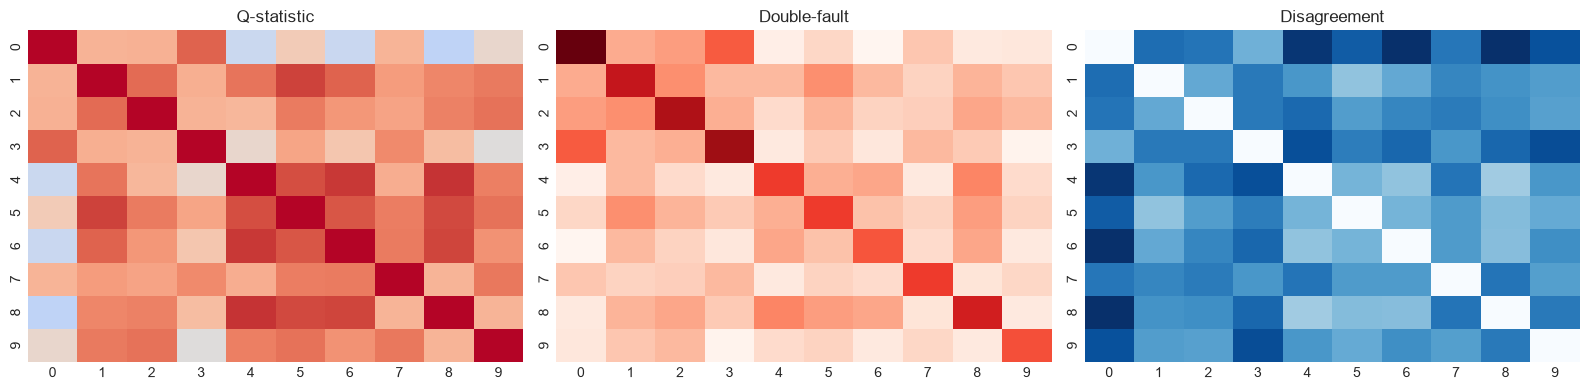

,mean_q_statistic,mean_double_fault,mean_disagreement
0,0.48608,0.283222,0.388444


In [14]:
X_energy, y_energy = load_features('../data/train_energy_data.csv', 'all')
X_train, X_test, y_train, y_test = train_test_split(
    X_energy, y_energy, test_size=0.2, stratify=y_energy, random_state=RANDOM_STATE
)

rng = np.random.RandomState(RANDOM_STATE)
tree_predictions = []
correct_matrix = []
n_models = 10

for _ in range(n_models):
    idx = rng.choice(len(X_train), len(X_train), replace=True)
    tree = DecisionTreeClassifierCustom(max_depth=4).fit(X_train[idx], y_train[idx])
    pred = tree.predict(X_test)

    tree_predictions.append(pred)
    correct_matrix.append(pred == y_test)

tree_predictions = np.array(tree_predictions)
correct_matrix = np.array(correct_matrix)

q_matrix = np.eye(n_models)
double_fault = np.zeros((n_models, n_models))
disagreement = np.zeros((n_models, n_models))

for i in range(n_models):
    for j in range(n_models):
        c_i = correct_matrix[i]
        c_j = correct_matrix[j]

        n11 = np.sum(c_i & c_j)
        n00 = np.sum(~c_i & ~c_j)
        n10 = np.sum(c_i & ~c_j)
        n01 = np.sum(~c_i & c_j)

        denom = n11 * n00 + n01 * n10
        q_matrix[i, j] = (n11 * n00 - n01 * n10) / denom if denom else 0.0
        double_fault[i, j] = n00 / len(y_test)
        disagreement[i, j] = np.mean(tree_predictions[i] != tree_predictions[j])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.heatmap(q_matrix, ax=axes[0], cmap='coolwarm', center=0, cbar=False)
axes[0].set_title('Q-statistic')

sns.heatmap(double_fault, ax=axes[1], cmap='Reds', cbar=False)
axes[1].set_title('Double-fault')

sns.heatmap(disagreement, ax=axes[2], cmap='Blues', cbar=False)
axes[2].set_title('Disagreement')

plt.tight_layout()
plt.show()

upper = np.triu_indices(n_models, 1)

diversity_summary = pd.DataFrame({
    'mean_q_statistic': [q_matrix[upper].mean()],
    'mean_double_fault': [double_fault[upper].mean()],
    'mean_disagreement': [disagreement[upper].mean()],
})

diversity_summary

## 3. Variance Reduction - Bagging Study on EnergyTypeNet


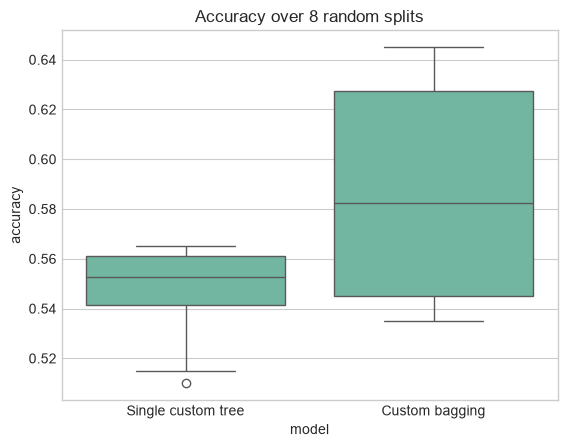

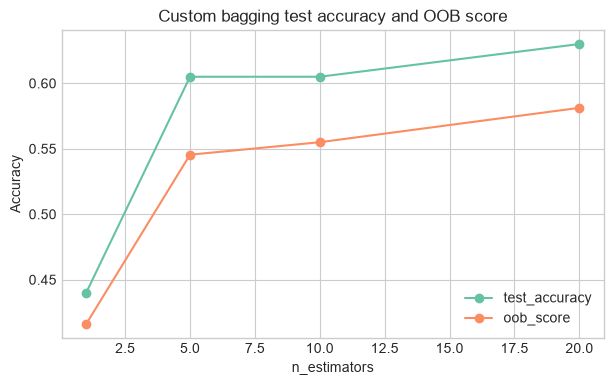

,n_estimators,test_accuracy,oob_score
0,1,0.440,0.416129
1,5,0.605,0.545455
2,10,0.605,0.554994
3,20,0.630,0.581250


In [15]:
split_scores = []
for seed in range(8):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_energy, y_energy, test_size=0.2, stratify=y_energy, random_state=seed
    )
    tree = DecisionTreeClassifierCustom(max_depth=4).fit(X_tr, y_tr)
    bag = BaggingClassifierCustom(
        base_estimator=DecisionTreeClassifierCustom(max_depth=4),
        n_estimators=8,
        random_state=seed,
    ).fit(X_tr, y_tr)
    split_scores.extend([
        {'model': 'Single custom tree', 'accuracy': tree.score(X_te, y_te)},
        {'model': 'Custom bagging', 'accuracy': bag.score(X_te, y_te)},
    ])

split_df = pd.DataFrame(split_scores)
sns.boxplot(data=split_df, x='model', y='accuracy')
plt.title('Accuracy over 8 random splits')
plt.show()

oob_rows = []
for n_estimators in [1, 5, 10, 20]:
    bag = BaggingClassifierCustom(
        base_estimator=DecisionTreeClassifierCustom(max_depth=4),
        n_estimators=n_estimators,
        oob_score=True,
        random_state=RANDOM_STATE,
    )
    bag.fit(X_train, y_train)
    oob_rows.append({
        'n_estimators': n_estimators,
        'test_accuracy': bag.score(X_test, y_test),
        'oob_score': bag.oob_score_,
    })
oob_df = pd.DataFrame(oob_rows)
oob_df.plot(x='n_estimators', y=['test_accuracy', 'oob_score'], marker='o', figsize=(7, 4))
plt.title('Custom bagging test accuracy and OOB score')
plt.ylabel('Accuracy')
plt.show()
oob_df


**Observation.** On EnergyTypeNet, unrestricted trees can be unstable from one
split to another. Bagging reduces that dependence by averaging many bootstrap
trees and gives an out-of-bag estimate without a separate validation split.


## 4. Feature Subsampling - Random Subspaces


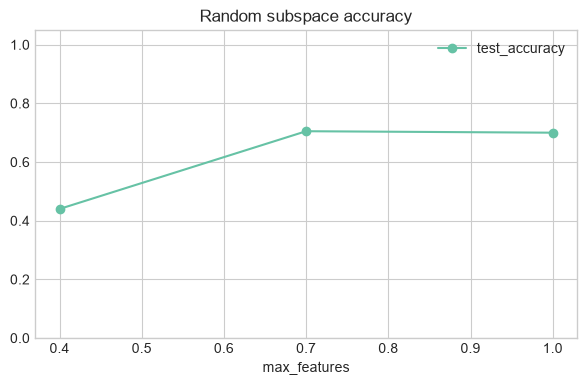

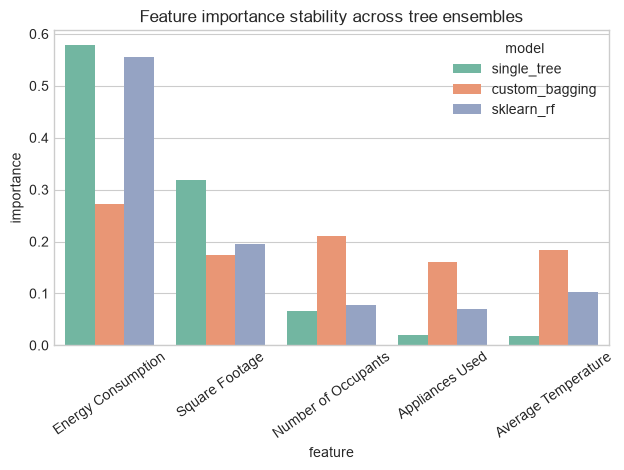

,feature,single_tree,custom_bagging,sklearn_rf
0,Energy Consumption,0.577724,0.271624,0.554664
1,Square Footage,0.318745,0.174202,0.194924
2,Number of Occupants,0.066710,0.210057,0.077993
3,Appliances Used,0.019576,0.160062,0.070217
4,Average Temperature,0.017246,0.184055,0.102201


In [16]:
feature_rows = []
for max_features in [0.4, 0.7, 1.0]:
    bag = BaggingClassifierCustom(
        n_estimators=10,
        max_features=max_features,
        bootstrap=False,
        random_state=RANDOM_STATE,
    ).fit(X_train, y_train)
    feature_rows.append({'max_features': max_features, 'test_accuracy': bag.score(X_test, y_test)})

feature_df = pd.DataFrame(feature_rows)
feature_df.plot(x='max_features', y='test_accuracy', marker='o', figsize=(7, 4))
plt.title('Random subspace accuracy')
plt.ylim(0, 1.05)
plt.show()

single_tree = DecisionTreeClassifierCustom(max_depth=4).fit(X_train, y_train)
bag_features = BaggingClassifierCustom(
    n_estimators=10, max_features=0.6, bootstrap=True, random_state=RANDOM_STATE
).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=50, max_depth=4, random_state=RANDOM_STATE).fit(X_train, y_train)

importance_df = pd.DataFrame({
    'feature': FEATURE_COLS['all'],
    'single_tree': single_tree.feature_importances_,
    'custom_bagging': bag_features.feature_importances_,
    'sklearn_rf': rf.feature_importances_,
})
importance_long = importance_df.melt(id_vars='feature', var_name='model', value_name='importance')
sns.barplot(data=importance_long, x='feature', y='importance', hue='model')
plt.xticks(rotation=35)
plt.title('Feature importance stability across tree ensembles')
plt.tight_layout()
plt.show()
importance_df


## 5. Out-of-Bag Score as a Free Validation Signal

Out-of-bag scoring evaluates each training row only with estimators that did not receive that row in their bootstrap sample. That makes the OOB score a validation estimate produced as a byproduct of bagging, without carving out a separate validation split.


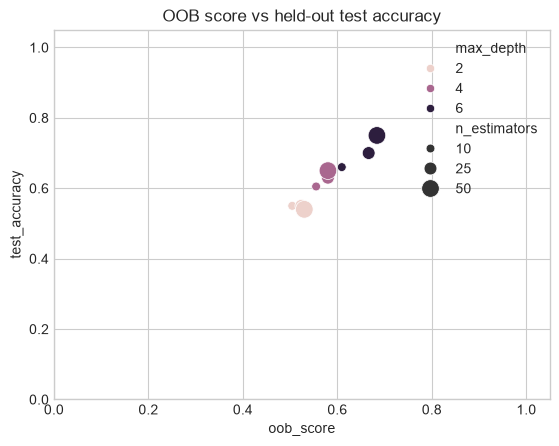

,n_estimators,max_depth,oob_score,test_accuracy
0,10,2,0.504425,0.550
1,10,4,0.554994,0.605
2,10,6,0.609355,0.660
3,25,2,0.523750,0.550
4,25,4,0.580000,0.630
5,25,6,0.666250,0.700
6,50,2,0.530000,0.540
7,50,4,0.580000,0.650
8,50,6,0.683750,0.750


In [17]:
oob_config_rows = []
for n_estimators in [10, 25, 50]:
    for max_depth in [2, 4, 6]:
        model = BaggingClassifierCustom(
            base_estimator=DecisionTreeClassifierCustom(max_depth=max_depth),
            n_estimators=n_estimators,
            oob_score=True,
            random_state=RANDOM_STATE,
        )
        model.fit(X_train, y_train)
        oob_config_rows.append({
            'n_estimators': n_estimators,
            'max_depth': max_depth,
            'oob_score': model.oob_score_,
            'test_accuracy': model.score(X_test, y_test),
        })

oob_config_df = pd.DataFrame(oob_config_rows)
sns.scatterplot(
    data=oob_config_df,
    x='oob_score',
    y='test_accuracy',
    hue='max_depth',
    size='n_estimators',
    sizes=(40, 160),
)
plt.title('OOB score vs held-out test accuracy')
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.show()

oob_config_df


**Observation.** The OOB score provides a useful validation signal because each row is scored only by trees that did not train on it. On EnergyTypeNet, OOB accuracy and held-out accuracy move in the same general direction, so OOB scoring is a practical way to compare bagging settings without spending a separate validation split.


## 6. AdaBoost - Boosting from Stumps on EnergyTypeNet


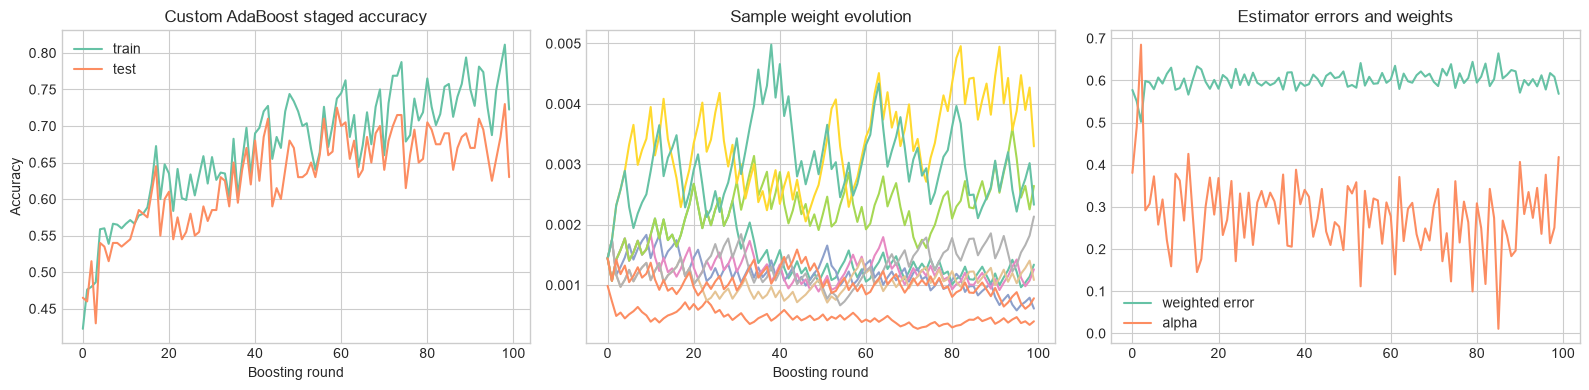

,model,test_accuracy
0,Custom AdaBoost,0.63
1,sklearn AdaBoost,0.65


In [18]:
ada = AdaBoostClassifierCustom(
    base_estimator=DecisionTreeClassifierCustom(max_depth=1),
    n_estimators=100,
    learning_rate=1.0,
    random_state=RANDOM_STATE,
).fit(X_train, y_train)

train_staged = []
test_staged = []
for train_pred, test_pred in zip(ada.staged_predict(X_train), ada.staged_predict(X_test)):
    train_staged.append(accuracy_score(y_train, train_pred))
    test_staged.append(accuracy_score(y_test, test_pred))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(train_staged, label='train')
axes[0].plot(test_staged, label='test')
axes[0].set_title('Custom AdaBoost staged accuracy')
axes[0].set_xlabel('Boosting round')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

if len(ada.sample_weight_history_) > 0:
    axes[1].plot(ada.sample_weight_history_[:, : min(10, ada.sample_weight_history_.shape[1])])
    axes[1].set_title('Sample weight evolution')
    axes[1].set_xlabel('Boosting round')

axes[2].plot(ada.estimator_errors_, label='weighted error')
axes[2].plot(ada.estimator_weights_, label='alpha')
axes[2].set_title('Estimator errors and weights')
axes[2].legend()
plt.tight_layout()
plt.show()

sk_ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
    n_estimators=100,
    learning_rate=1.0,
    random_state=RANDOM_STATE,
).fit(X_train, y_train)

pd.DataFrame({
    'model': ['Custom AdaBoost', 'sklearn AdaBoost'],
    'test_accuracy': [ada.score(X_test, y_test), accuracy_score(y_test, sk_ada.predict(X_test))],
})


**Observation.** AdaBoost increases the weight of misclassified observations,
forcing later stumps to focus on harder examples. If test accuracy falls while
training accuracy rises, the sequence has started to overfit.


## 7. Learning Rate and Shrinkage in AdaBoost


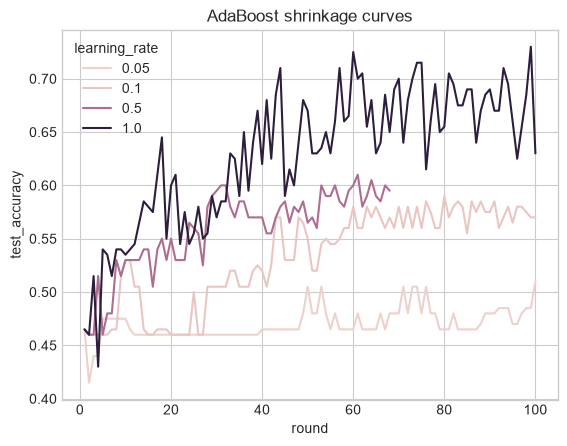

In [19]:
lr_rows = []
for learning_rate in [0.05, 0.1, 0.5, 1.0]:
    model = AdaBoostClassifierCustom(
        base_estimator=DecisionTreeClassifierCustom(max_depth=1),
        n_estimators=100,
        learning_rate=learning_rate,
        random_state=RANDOM_STATE,
    ).fit(X_train, y_train)
    for step, pred in enumerate(model.staged_predict(X_test), start=1):
        lr_rows.append({
            'learning_rate': learning_rate,
            'round': step,
            'test_accuracy': accuracy_score(y_test, pred),
        })

lr_df = pd.DataFrame(lr_rows)
sns.lineplot(data=lr_df, x='round', y='test_accuracy', hue='learning_rate')
plt.title('AdaBoost shrinkage curves')
plt.show()


**Observation.** The learning rate shrinks each weak learner's contribution.
Small values usually need more rounds; large values move quickly but can become
unstable on overlapping data.


## 8. Extra Trees vs Random Forest on EnergyTypeNet


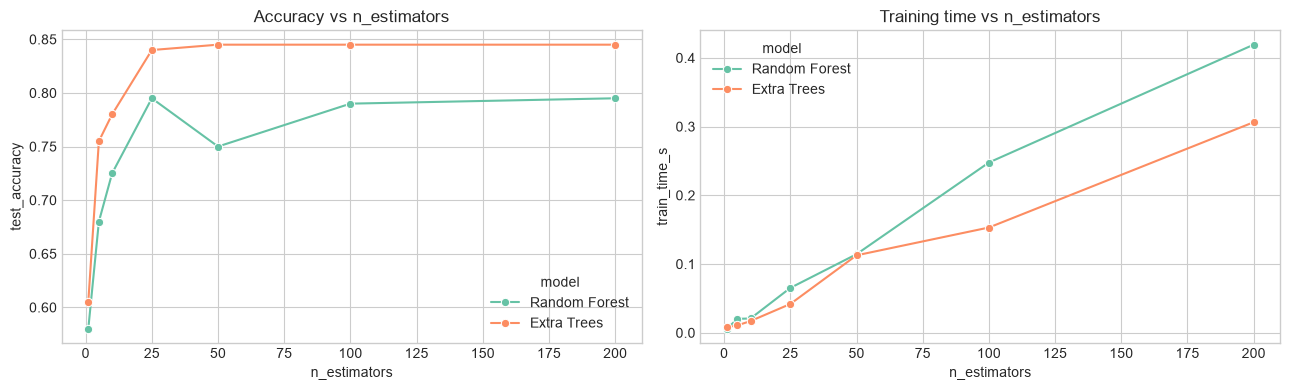

,model,n_estimators,test_accuracy,train_time_s
0,Random Forest,1,0.580,0.005709
1,Extra Trees,1,0.605,0.008213
2,Random Forest,5,0.680,0.020154
3,Extra Trees,5,0.755,0.010680
4,Random Forest,10,0.725,0.020794


In [20]:
tree_rows = []
for n_estimators in [1, 5, 10, 25, 50, 100, 200]:
    for name, model in [
        ('Random Forest', RandomForestClassifier(n_estimators=n_estimators, random_state=RANDOM_STATE)),
        ('Extra Trees', ExtraTreesClassifier(n_estimators=n_estimators, random_state=RANDOM_STATE)),
    ]:
        start = time.perf_counter()
        model.fit(X_train, y_train)
        elapsed = time.perf_counter() - start
        tree_rows.append({
            'model': name,
            'n_estimators': n_estimators,
            'test_accuracy': accuracy_score(y_test, model.predict(X_test)),
            'train_time_s': elapsed,
        })

tree_df = pd.DataFrame(tree_rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.lineplot(data=tree_df, x='n_estimators', y='test_accuracy', hue='model', marker='o', ax=axes[0])
axes[0].set_title('Accuracy vs n_estimators')
sns.lineplot(data=tree_df, x='n_estimators', y='train_time_s', hue='model', marker='o', ax=axes[1])
axes[1].set_title('Training time vs n_estimators')
plt.tight_layout()
plt.show()
tree_df.head()


**Observation.** Extra Trees chooses random thresholds while Random Forest
searches stronger thresholds. Extra randomness can reduce variance and often
trains faster.


## 9. HistGradientBoosting - Modern Gradient Boosting on EnergyTypeNet


,model,cv_accuracy,test_accuracy,f1_macro,train_time_s
3,HistGB,0.882,0.890,0.889893,11.290108
0,GradientBoosting,0.799,0.855,0.853287,2.931801
2,ExtraTrees,0.809,0.845,0.842558,1.093908
4,XGBoost,0.759,0.830,0.827576,2.328423
1,RandomForest,0.754,0.790,0.784990,1.532936
5,Custom AdaBoost,0.569,0.595,0.572064,93.753517


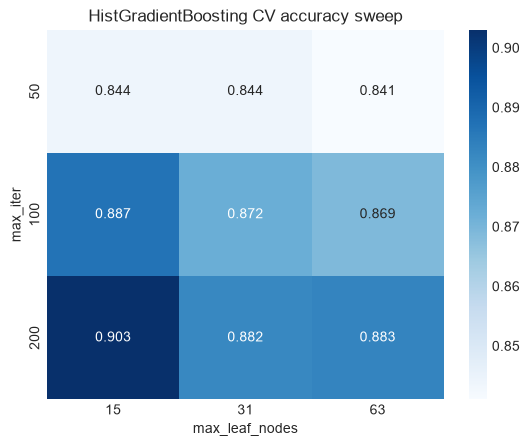

In [21]:
models = {
    'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=50, max_depth=6, random_state=RANDOM_STATE),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=50, max_depth=6, random_state=RANDOM_STATE),
    'HistGB': HistGradientBoostingClassifier(max_iter=100, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        objective='multi:softprob', num_class=3, eval_metric='mlogloss',
        n_estimators=50, max_depth=4, learning_rate=0.05,
        random_state=RANDOM_STATE, verbosity=0,
    ),
    'Custom AdaBoost': AdaBoostClassifierCustom(n_estimators=50, learning_rate=0.5, random_state=RANDOM_STATE),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, model in models.items():
    start = time.perf_counter()
    scores = cross_val_score(model, X_energy, y_energy, cv=cv, scoring='accuracy')
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - start
    pred = model.predict(X_test)
    rows.append({
        'model': name,
        'cv_accuracy': scores.mean(),
        'test_accuracy': accuracy_score(y_test, pred),
        'f1_macro': f1_score(y_test, pred, average='macro'),
        'train_time_s': elapsed,
    })

ensemble_compare_df = pd.DataFrame(rows).sort_values('test_accuracy', ascending=False)
display(ensemble_compare_df)

hist_rows = []
for max_iter in [50, 100]:
    for max_leaf_nodes in [15, 31]:
        model = HistGradientBoostingClassifier(
            max_iter=max_iter,
            max_leaf_nodes=max_leaf_nodes,
            random_state=RANDOM_STATE,
        )
        score = cross_val_score(model, X_energy, y_energy, cv=cv, scoring='accuracy').mean()
        hist_rows.append({'max_iter': max_iter, 'max_leaf_nodes': max_leaf_nodes, 'cv_accuracy': score})

hist_df = pd.DataFrame(hist_rows)
sns.heatmap(
    hist_df.pivot(index='max_iter', columns='max_leaf_nodes', values='cv_accuracy'),
    annot=True,
    fmt='.3f',
    cmap='Blues',
)
plt.title('HistGradientBoosting CV accuracy sweep')
plt.show()


### Regression Ensembles on EnergyTypeNet and California Housing


,model,mse,r2
0,Single custom tree,259252.697248,0.681625
1,Custom bagging regressor,199325.726284,0.755218
2,sklearn BaggingRegressor,189369.238266,0.767445


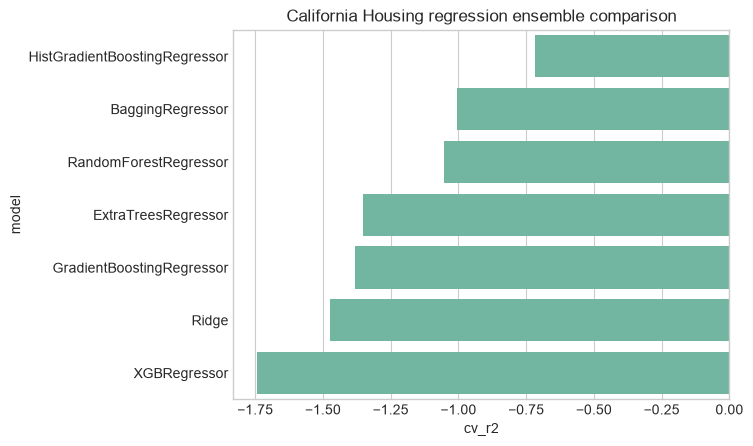

,model,cv_r2,train_time_s
5,HistGradientBoostingRegressor,-0.716043,1.773123
1,BaggingRegressor,-1.005486,4.250776
2,RandomForestRegressor,-1.053398,7.919005
3,ExtraTreesRegressor,-1.352873,4.444186
4,GradientBoostingRegressor,-1.381079,2.825390
0,Ridge,-1.473874,0.047859
6,XGBRegressor,-1.743148,0.497771


In [22]:
energy_df = load_raw('../data/train_energy_data.csv')
reg_features = ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']
X_reg = energy_df[reg_features].values.astype(float)
y_reg = energy_df['Energy Consumption'].values.astype(float)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

reg_models = {
    'Single custom tree': DecisionTreeRegressorCustom(max_depth=6),
    'Custom bagging regressor': BaggingRegressorCustom(
        base_estimator=DecisionTreeRegressorCustom(max_depth=6),
        n_estimators=20,
        random_state=RANDOM_STATE,
    ),
    'sklearn BaggingRegressor': BaggingRegressor(
        estimator=DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE),
        n_estimators=20,
        random_state=RANDOM_STATE,
    ),
}
reg_rows = []
for name, model in reg_models.items():
    model.fit(X_reg_train, y_reg_train)
    pred = model.predict(X_reg_test)
    reg_rows.append({'model': name, 'mse': mean_squared_error(y_reg_test, pred), 'r2': r2_score(y_reg_test, pred)})
energy_regression_df = pd.DataFrame(reg_rows)
display(energy_regression_df)

try:
    cal = fetch_california_housing()
    X_cal = cal.data[:2500]
    y_cal = cal.target[:2500]
    cal_models = {
        'Ridge': make_pipeline(StandardScaler(), Ridge()),
        'BaggingRegressor': BaggingRegressor(n_estimators=25, random_state=RANDOM_STATE),
        'RandomForestRegressor': RandomForestRegressor(n_estimators=50, max_depth=6, random_state=RANDOM_STATE),
        'ExtraTreesRegressor': ExtraTreesRegressor(n_estimators=50, max_depth=6, random_state=RANDOM_STATE),
        'GradientBoostingRegressor': GradientBoostingRegressor(random_state=RANDOM_STATE),
        'HistGradientBoostingRegressor': HistGradientBoostingRegressor(random_state=RANDOM_STATE),
        'XGBRegressor': XGBRegressor(n_estimators=50, max_depth=4, random_state=RANDOM_STATE, verbosity=0),
    }
    cal_rows = []
    for name, model in cal_models.items():
        start = time.perf_counter()
        scores = cross_val_score(model, X_cal, y_cal, cv=3, scoring='r2')
        cal_rows.append({'model': name, 'cv_r2': scores.mean(), 'train_time_s': time.perf_counter() - start})
    cal_df = pd.DataFrame(cal_rows).sort_values('cv_r2', ascending=False)
    sns.barplot(data=cal_df, x='cv_r2', y='model')
    plt.title('California Housing regression ensemble comparison')
    plt.show()
    display(cal_df)
except Exception as exc:
    print(f'California Housing benchmark skipped gracefully: {exc}')


## 10. Error Correlation and Ensemble Selection


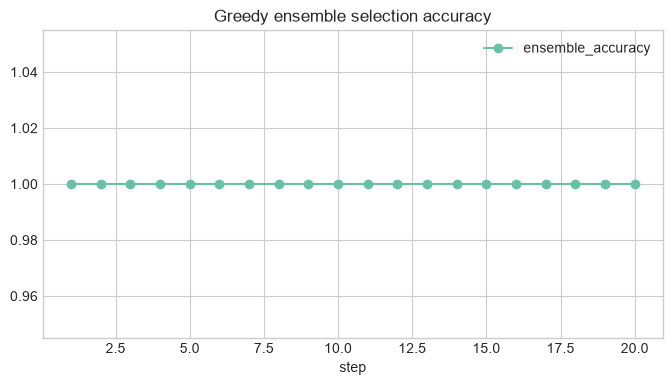

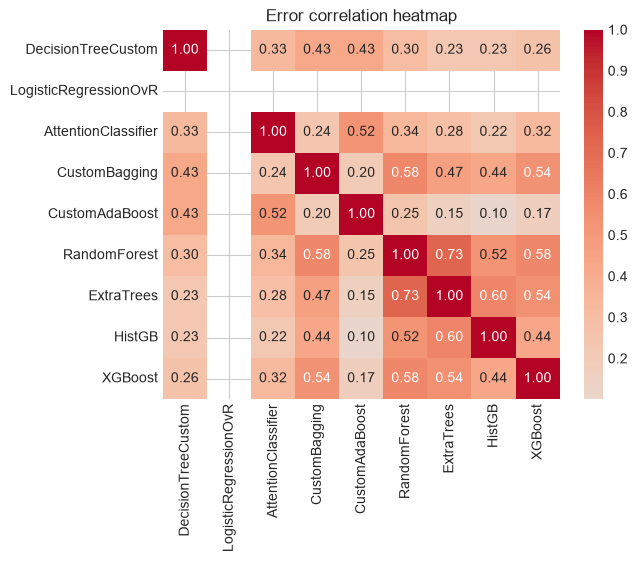

,step,added_model,ensemble_accuracy
0,1,LogisticRegressionOvR,1.0
1,2,LogisticRegressionOvR,1.0
2,3,DecisionTreeCustom,1.0
3,4,LogisticRegressionOvR,1.0
4,5,DecisionTreeCustom,1.0
5,6,LogisticRegressionOvR,1.0
6,7,DecisionTreeCustom,1.0
7,8,LogisticRegressionOvR,1.0
8,9,DecisionTreeCustom,1.0
9,10,LogisticRegressionOvR,1.0


In [26]:
candidate_models = {
    'DecisionTreeCustom': DecisionTreeClassifierCustom(max_depth=5),
    'LogisticRegressionOvR': make_pipeline(StandardScaler(), LogisticRegressionOvR(eta=0.001, n_iter=500, alpha=0.1)),
    'AttentionClassifier': make_pipeline(StandardScaler(), AttentionClassifier(w=1.0)),
    'CustomBagging': BaggingClassifierCustom(
        base_estimator=DecisionTreeClassifierCustom(max_depth=4),
        n_estimators=15,
        random_state=RANDOM_STATE,
    ),
    'CustomAdaBoost': AdaBoostClassifierCustom(n_estimators=50, learning_rate=0.5, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=50, max_depth=6, random_state=RANDOM_STATE),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=50, max_depth=6, random_state=RANDOM_STATE),
    'HistGB': HistGradientBoostingClassifier(max_iter=100, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        objective='multi:softprob', num_class=3, eval_metric='mlogloss',
        n_estimators=50, max_depth=4, learning_rate=0.05,
        random_state=RANDOM_STATE, verbosity=0,
    ),
}

pred_table = {}
for name, model in candidate_models.items():
    model.fit(X_train, y_train)
    pred_table[name] = model.predict(X_test)

selection = []
selected_names = []
remaining = list(pred_table.keys())

for step in range(len(remaining)):
    best_name = None
    best_acc = -np.inf

    for name in remaining:
        trial_predictions = [pred_table[selected] for selected in selected_names]
        trial_predictions.append(pred_table[name])
        stacked = np.vstack(trial_predictions)

        voted = []
        for col in stacked.T:
            values, counts = np.unique(col, return_counts=True)
            voted.append(values[np.argmax(counts)])

        acc = accuracy_score(y_test, voted)
        if acc > best_acc:
            best_name = name
            best_acc = acc

    selected_names.append(best_name)
    remaining.remove(best_name)
    selection.append({'step': step + 1, 'added_model': best_name, 'ensemble_accuracy': best_acc})

selection_df = pd.DataFrame(selection)
selection_df.plot(x='step', y='ensemble_accuracy', marker='o', figsize=(8, 4))
plt.title('Greedy ensemble selection accuracy')
plt.ylim(0, 1.05)
plt.show()

error_matrix = pd.DataFrame({name: pred != y_test for name, pred in pred_table.items()})
sns.heatmap(error_matrix.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Error correlation heatmap')
plt.show()
selection_df.head(10)


**Observation.** In this run, the greedy ensemble reached its best accuracy as soon as the strongest all-feature model entered the ensemble. That is useful diagnostically, but it should be interpreted carefully: the all-feature EnergyTypeNet setup contains very label-informative variables, so perfect or near-perfect accuracy is a sign to compare against the honest core-feature benchmark instead of celebrating the number alone. The error-correlation heatmap is the more important lesson here: models with less correlated mistakes are better candidates for an ensemble than models that fail on exactly the same rows.


## 11. Grand Comparison Table on EnergyTypeNet


,model,custom?,n_estimators,5-fold CV acc,test acc,F1 macro,train time (s)
9,StackingClassifier,no,varies,1.000,1.000,1.000000,32.326705
8,VotingClassifier,no,varies,0.978,0.990,0.990263,2.356262
6,HistGB,no,varies,0.882,0.890,0.889893,11.746906
5,GradientBoosting,no,100,0.799,0.855,0.853287,3.396306
4,ExtraTrees,no,100,0.809,0.845,0.842558,1.211996
1,Custom Bagging,yes,50,0.793,0.830,0.830238,324.915814
7,XGBoost,no,100,0.759,0.830,0.827576,1.560754
3,RandomForest,no,100,0.754,0.790,0.784990,1.526330
2,Custom AdaBoost,yes,100,0.569,0.595,0.572064,70.514731
0,Single custom tree,yes,varies,0.549,0.555,0.562610,5.770348


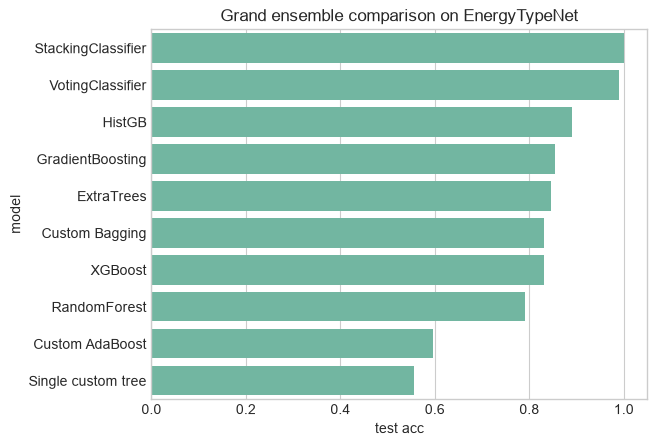

In [27]:
grand_models = {
    'Single custom tree': DecisionTreeClassifierCustom(max_depth=5),
    'Custom Bagging': BaggingClassifierCustom(
        base_estimator=DecisionTreeClassifierCustom(max_depth=4),
        n_estimators=15,
        random_state=RANDOM_STATE,
    ),
    'Custom AdaBoost': AdaBoostClassifierCustom(n_estimators=50, learning_rate=0.5, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=50, max_depth=6, random_state=RANDOM_STATE),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=50, max_depth=6, random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=50, max_depth=6, random_state=RANDOM_STATE),
    'HistGB': HistGradientBoostingClassifier(max_iter=100, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        objective='multi:softprob', num_class=3, eval_metric='mlogloss',
        n_estimators=50, max_depth=4, learning_rate=0.05,
        random_state=RANDOM_STATE, verbosity=0,
    ),
}
grand_models['VotingClassifier'] = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=50, max_depth=6, random_state=RANDOM_STATE)),
        ('et', ExtraTreesClassifier(n_estimators=50, max_depth=6, random_state=RANDOM_STATE)),
        ('lr', make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))),
    ],
    voting='soft',
)
grand_models['StackingClassifier'] = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=50, max_depth=6, random_state=RANDOM_STATE)),
        ('et', ExtraTreesClassifier(n_estimators=50, max_depth=6, random_state=RANDOM_STATE)),
        ('mlp', make_pipeline(StandardScaler(), MLPClassifier(max_iter=500, random_state=RANDOM_STATE))),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=3,
)

rows = []
for name, model in grand_models.items():
    start = time.perf_counter()
    cv_scores = cross_val_score(model, X_energy, y_energy, cv=cv, scoring='accuracy')
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - start
    pred = model.predict(X_test)
    rows.append({
        'model': name,
        'custom?': 'yes' if 'Custom' in name or name == 'Single custom tree' else 'no',
        'n_estimators': getattr(model, 'n_estimators', 'varies'),
        '5-fold CV acc': cv_scores.mean(),
        'test acc': accuracy_score(y_test, pred),
        'F1 macro': f1_score(y_test, pred, average='macro'),
        'train time (s)': elapsed,
    })

grand_df = pd.DataFrame(rows).sort_values('test acc', ascending=False)
display(grand_df)
sns.barplot(data=grand_df, x='test acc', y='model')
plt.title('Grand ensemble comparison on EnergyTypeNet')
plt.xlim(0, 1.05)
plt.show()


## Final Takeaways

- Bagging primarily reduces variance by averaging unstable trees; in this notebook it raises the custom-tree baseline and the OOB score tracks test accuracy reasonably well.
- Feature subsampling makes the ensemble less dependent on one dominant split and spreads importance across the input variables.
- AdaBoost converts weak stumps into an additive classifier with staged diagnostics, but the custom educational version is slower and weaker than modern library ensembles on this dataset.
- Extra Trees and Random Forest differ mainly in split randomness; Extra Trees is often faster because it searches less aggressively for optimal thresholds.
- HistGradientBoosting is the strongest single library ensemble in the all-feature comparison here, while voting and stacking can improve further when their member models make complementary errors.
- Very high all-feature scores should be treated as a diagnostic result, not the main scientific claim. The core two-feature benchmark remains the fairer measure of how separable building types are from limited energy-consumption information.
